### Imports and configuration

In [ ]:

import json
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import scipy.sparse as sp

import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.preprocessing import label_binarize

sns.set_theme(style="whitegrid", palette="muted")

RANDOM_STATE = 42
TEST_SIZE = 0.20


CWD = Path.cwd()
PROJECT_ROOT = CWD.parent
DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed data directory:", DATA_DIR)


Project root: /home/patryk/Programming/MIO/social-media-engagement-prediction
Processed data directory: /home/patryk/Programming/MIO/social-media-engagement-prediction/data/processed


### Loading processed features and metadata

In [7]:

X_tfidf = sp.load_npz(DATA_DIR / "X_tfidf_features.npz")
X_count = sp.load_npz(DATA_DIR / "X_count_features.npz")

y = np.load(DATA_DIR / "y_labels.npy")
label_classes = np.load(DATA_DIR / "label_classes.npy", allow_pickle=True)

with open(DATA_DIR / "feature_names_tfidf.json", "r") as f:
    feature_names_tfidf = json.load(f)

with open(DATA_DIR / "feature_names_count.json", "r") as f:
    feature_names_count = json.load(f)

_df_path = DATA_DIR / "df_with_features.csv"
df = pd.read_csv(_df_path) if _df_path.exists() else None

print("X_tfidf:", X_tfidf.shape)
print("X_count:", X_count.shape)
print("y:", y.shape)
print("Classes:", dict(enumerate(label_classes)))
print("TF-IDF feature names:", len(feature_names_tfidf))
print("Count feature names:", len(feature_names_count))

assert X_tfidf.shape[0] == len(y), "X_tfidf row count does not match y length."
assert X_count.shape[0] == len(y), "X_count row count does not match y length."
assert X_tfidf.shape[1] == len(feature_names_tfidf), "TF-IDF feature-name count mismatch."
assert X_count.shape[1] == len(feature_names_count), "Count feature-name count mismatch."

if df is not None:
    assert len(df) == len(y), "df_with_features.csv row count does not match y length."


X_tfidf: (43352, 10023)
X_count: (43352, 10023)
y: (43352,)
Classes: {0: 'High', 1: 'Low', 2: 'Medium'}
TF-IDF feature names: 10023
Count feature names: 10023


### Train/test split

In [8]:

all_indices = np.arange(len(y))

train_idx, test_idx = train_test_split(
    all_indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

y_train = y[train_idx]
y_test = y[test_idx]

X_train_tfidf = X_tfidf[train_idx]
X_test_tfidf = X_tfidf[test_idx]

X_train_count = X_count[train_idx]
X_test_count = X_count[test_idx]

print("Train size:", len(train_idx))
print("Test size: ", len(test_idx))
print("TF-IDF train/test:", X_train_tfidf.shape, X_test_tfidf.shape)
print("Count train/test: ", X_train_count.shape, X_test_count.shape)

np.save(DATA_DIR / "train_indices.npy", train_idx)
np.save(DATA_DIR / "test_indices.npy", test_idx)


Train size: 34681
Test size:  8671
TF-IDF train/test: (34681, 10023) (8671, 10023)
Count train/test:  (34681, 10023) (8671, 10023)


## Model benchmark

Models:

- **Logistic Regression** on TF-IDF + numeric features.
- **Linear SVM** on TF-IDF + numeric features.
- **SGDClassifier** with logistic loss on TF-IDF + numeric features.
- **Logistic Regression** on CountVectorizer + numeric features.
- **Linear SVM** on CountVectorizer + numeric features.
- **XGBoost**

Metrics:

- `accuracy` — overall fraction of correct predictions.
- `balanced_accuracy` — average recall per class.
- `macro_f1` — F1 averaged equally across classes.
- `weighted_f1` — F1 averaged by class support.

In [10]:

def get_scores_for_auc(model: object, X: object) -> object:
    """
    Return class scores/probabilities if the model supports them; otherwise None.
    """
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return None


def evaluate_model(model_name: str, representation: str, model: object, X_train: object, X_test: object, feature_names: list):
    """
    Evaluate a model on the provided training and test data, returning performance metrics and predictions.
    """
    start = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - start

    y_pred = model.predict(X_test)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted", zero_division=0
    )

    scores = get_scores_for_auc(model, X_test)
    roc_auc_ovr_weighted = np.nan
    if scores is not None:
        try:
            roc_auc_ovr_weighted = roc_auc_score(
                y_test, scores, multi_class="ovr", average="weighted"
            )
        except Exception:
            roc_auc_ovr_weighted = np.nan

    result = {
        "model_name": model_name,
        "representation": representation,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "macro_precision": precision_macro,
        "macro_recall": recall_macro,
        "macro_f1": f1_macro,
        "weighted_precision": precision_weighted,
        "weighted_recall": recall_weighted,
        "weighted_f1": f1_weighted,
        "roc_auc_ovr_weighted": roc_auc_ovr_weighted,
        "fit_time_sec": fit_time,
    }

    return result, model, y_pred, scores, feature_names


In [ ]:

experiments = [
    {
        "model_name": "Logistic Regression — TF-IDF + numeric",
        "representation": "tfidf+numeric",
        "model": LogisticRegression(max_iter=2000, solver="saga", class_weight="balanced", random_state=RANDOM_STATE),
        "X_train": X_train_tfidf,
        "X_test": X_test_tfidf,
        "feature_names": feature_names_tfidf,
    },
    {
        "model_name": "Linear SVM — TF-IDF + numeric",
        "representation": "tfidf+numeric",
        "model": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, max_iter=5000),
        "X_train": X_train_tfidf,
        "X_test": X_test_tfidf,
        "feature_names": feature_names_tfidf,
    },
    {
        "model_name": "SGD log-loss — TF-IDF + numeric",
        "representation": "tfidf+numeric",
        "model": SGDClassifier(loss="log_loss", penalty="elasticnet", alpha=1e-5, l1_ratio=0.15, max_iter=2000, tol=1e-3, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
        "X_train": X_train_tfidf,
        "X_test": X_test_tfidf,
        "feature_names": feature_names_tfidf,
    },
    {
        "model_name": "Logistic Regression — Count + numeric",
        "representation": "count+numeric",
        "model": LogisticRegression(max_iter=2000, solver="saga", class_weight="balanced", random_state=RANDOM_STATE),
        "X_train": X_train_count,
        "X_test": X_test_count,
        "feature_names": feature_names_count,
    },
    {
        "model_name": "Linear SVM — Count + numeric",
        "representation": "count+numeric",
        "model": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, max_iter=5000),
        "X_train": X_train_count,
        "X_test": X_test_count,
        "feature_names": feature_names_count,
    },
    {
        "model_name": "XGBoost — TF-IDF + numeric",
        "representation": "tfidf+numeric",
        "model": XGBClassifier(
            objective="multi:softprob",
            eval_metric="mlogloss",
            num_class=len(label_classes),
            n_estimators=250,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "X_train": X_train_tfidf,
        "X_test": X_test_tfidf,
        "feature_names": feature_names_tfidf,
    }
]


In [12]:

results = []
fitted_models = {}
predictions = {}
score_outputs = {}
model_feature_names = {}

for exp in experiments:
    print(f"Training: {exp['model_name']} ...")
    result, fitted_model, y_pred, scores, f_names = evaluate_model(
        exp["model_name"], exp["representation"], exp["model"], exp["X_train"], exp["X_test"], exp["feature_names"]
    )
    results.append(result)
    fitted_models[exp["model_name"]] = fitted_model
    predictions[exp["model_name"]] = y_pred
    score_outputs[exp["model_name"]] = scores
    model_feature_names[exp["model_name"]] = f_names
    print(f"  macro F1={result['macro_f1']:.4f}, accuracy={result['accuracy']:.4f}, fit_time={result['fit_time_sec']:.1f}s")

results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False).reset_index(drop=True)
results_df.to_csv(DATA_DIR / "model_benchmark_results.csv", index=False)

display(results_df)


Training: Logistic Regression — TF-IDF + numeric ...


/home/patryk/Programming/MIO/social-media-engagement-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  macro F1=0.8049, accuracy=0.8051, fit_time=24.8s
Training: Linear SVM — TF-IDF + numeric ...
  macro F1=0.8061, accuracy=0.8073, fit_time=28.1s
Training: SGD log-loss — TF-IDF + numeric ...
  macro F1=0.7885, accuracy=0.7905, fit_time=0.9s
Training: Logistic Regression — Count + numeric ...


/home/patryk/Programming/MIO/social-media-engagement-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  macro F1=0.8013, accuracy=0.8022, fit_time=29.4s
Training: Linear SVM — Count + numeric ...
  macro F1=0.7780, accuracy=0.7791, fit_time=33.7s
Training: XGBoost — TF-IDF + numeric ...
  macro F1=0.7845, accuracy=0.7854, fit_time=116.9s


,model_name,representation,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,roc_auc_ovr_weighted,fit_time_sec
0,Linear SVM — TF-IDF + numeric,tfidf+numeric,0.807289,0.807074,0.805756,0.807074,0.806059,0.805848,0.807289,0.806212,NaN,28.067484
1,Logistic Regression — TF-IDF + numeric,tfidf+numeric,0.805097,0.804928,0.804948,0.804928,0.804887,0.805077,0.805097,0.805036,0.932962,24.810613
2,Logistic Regression — Count + numeric,count+numeric,0.802214,0.802011,0.800960,0.802011,0.801318,0.801079,0.802214,0.801479,0.928088,29.421817
3,SGD log-loss — TF-IDF + numeric,tfidf+numeric,0.790451,0.790182,0.788311,0.790182,0.788523,0.788406,0.790451,0.788706,0.923514,0.941307
4,XGBoost — TF-IDF + numeric,tfidf+numeric,0.785377,0.785083,0.786301,0.785083,0.784454,0.786393,0.785377,0.784644,0.925310,116.852287
5,Linear SVM — Count + numeric,count+numeric,0.779149,0.778916,0.777709,0.778916,0.778017,0.777829,0.779149,0.778194,NaN,33.659337


### Visualizations

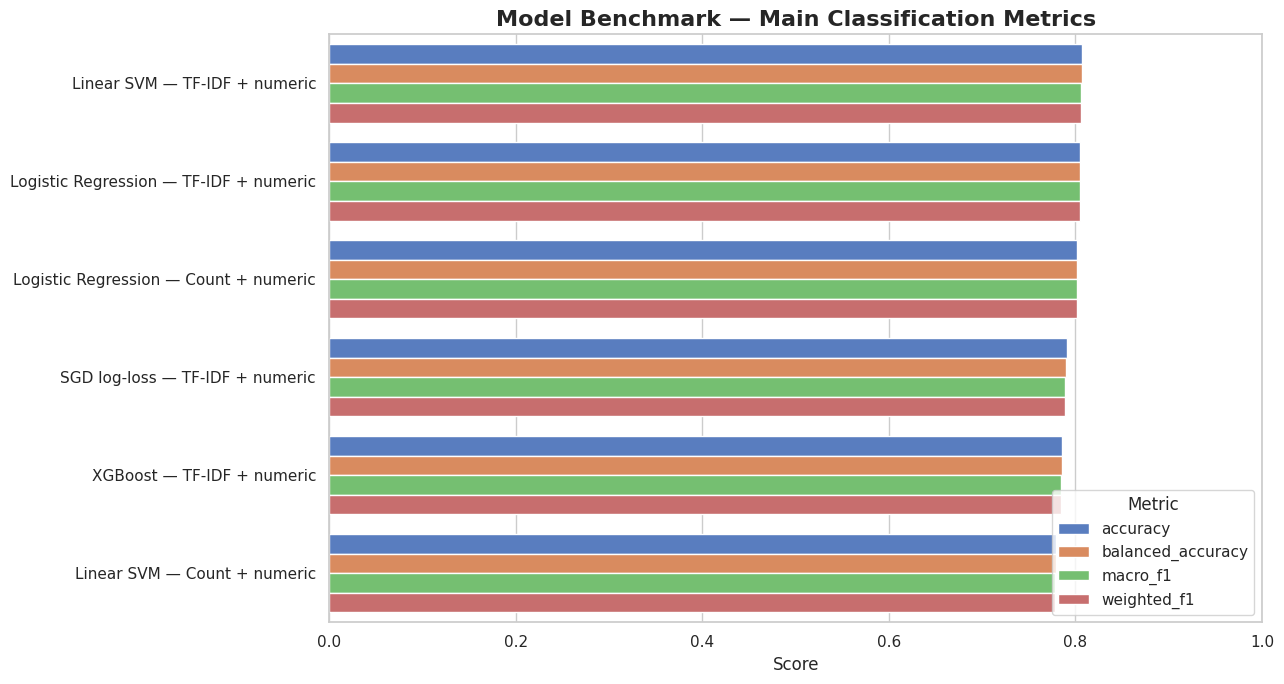

In [13]:

metric_cols = ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]
plot_df = results_df.melt(
    id_vars=["model_name", "representation"],
    value_vars=metric_cols,
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(13, 7))
sns.barplot(data=plot_df, y="model_name", x="score", hue="metric")
plt.title("Model Benchmark — Main Classification Metrics", fontsize=16, fontweight="bold")
plt.xlabel("Score")
plt.ylabel("")
plt.xlim(0, 1)
plt.legend(title="Metric", loc="lower right")
plt.tight_layout()
plt.show()


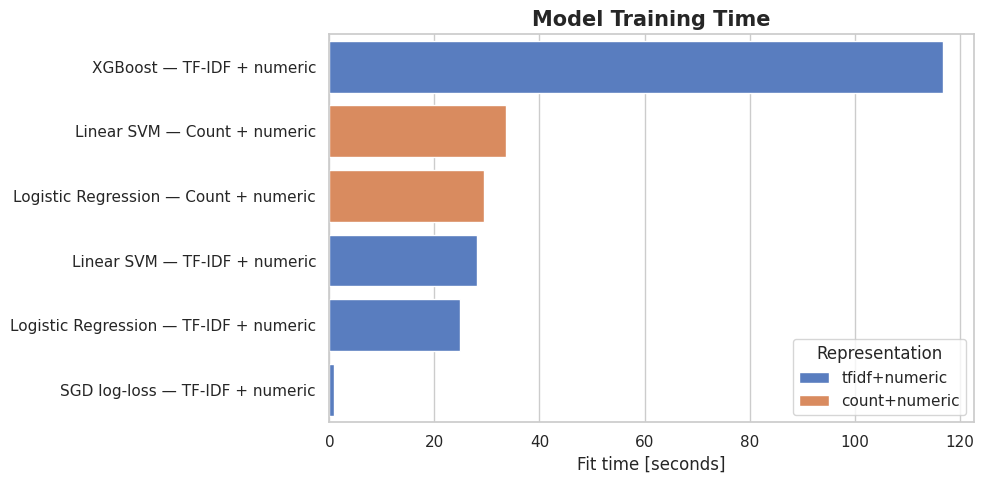

In [14]:

plt.figure(figsize=(10, 5))
sns.barplot(
    data=results_df.sort_values("fit_time_sec", ascending=False),
    y="model_name",
    x="fit_time_sec",
    hue="representation",
    dodge=False,
)
plt.title("Model Training Time", fontsize=15, fontweight="bold")
plt.xlabel("Fit time [seconds]")
plt.ylabel("")
plt.legend(title="Representation")
plt.tight_layout()
plt.show()


### Best model details

In [15]:

best_model_name = results_df.loc[0, "model_name"]
best_model = fitted_models[best_model_name]
best_pred = predictions[best_model_name]
best_scores = score_outputs[best_model_name]
best_feature_names = model_feature_names[best_model_name]

print("Best model:", best_model_name)
print("Representation:", results_df.loc[0, "representation"])
print("Macro F1:", results_df.loc[0, "macro_f1"])
print("Accuracy:", results_df.loc[0, "accuracy"])

report = classification_report(y_test, best_pred, target_names=label_classes, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
report_df.to_csv(DATA_DIR / "best_model_classification_report.csv")
display(report_df)


Best model: Linear SVM — TF-IDF + numeric
Representation: tfidf+numeric
Macro F1: 0.8060589008203913
Accuracy: 0.8072886633606273


,precision,recall,f1-score,support
High,0.870085,0.880623,0.875322,2890.000000
Low,0.804283,0.840565,0.822024,2904.000000
Medium,0.742899,0.700035,0.720830,2877.000000
accuracy,0.807289,0.807289,0.807289,0.807289
macro avg,0.805756,0.807074,0.806059,8671.000000
weighted avg,0.805848,0.807289,0.806212,8671.000000


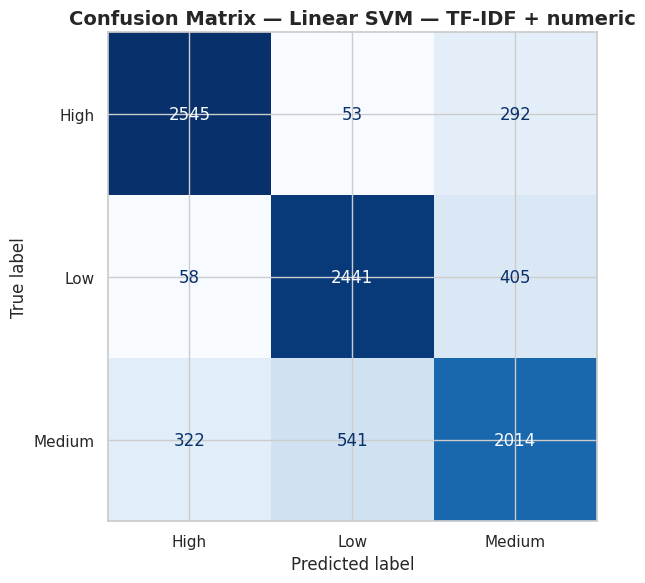

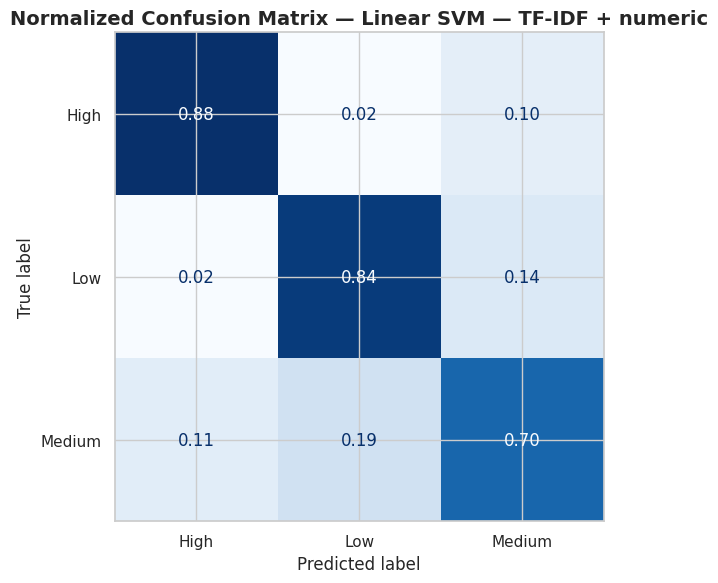

In [16]:

cm = confusion_matrix(y_test, best_pred, labels=np.arange(len(label_classes)))

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_classes)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title(f"Confusion Matrix — {best_model_name}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

cm_norm = confusion_matrix(y_test, best_pred, labels=np.arange(len(label_classes)), normalize="true")
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=label_classes)
disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
plt.title(f"Normalized Confusion Matrix — {best_model_name}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### Confusion matrices for top models

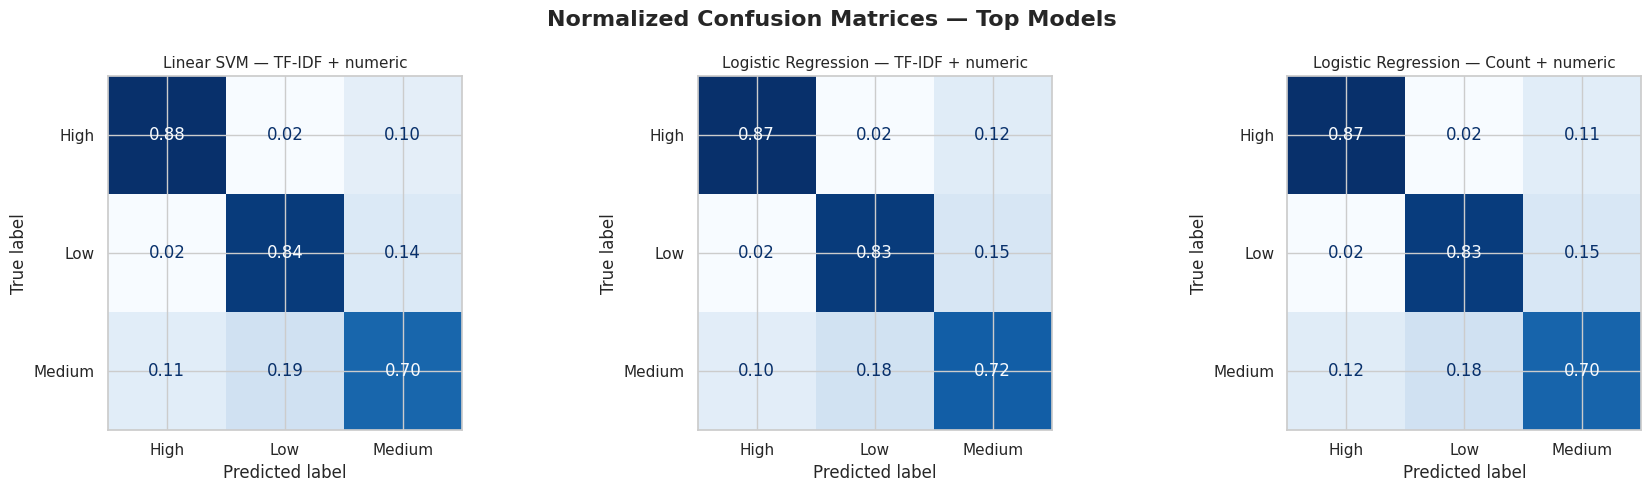

In [17]:

top_n = min(3, len(results_df))
top_model_names = results_df.head(top_n)["model_name"].tolist()

fig, axes = plt.subplots(1, top_n, figsize=(6 * top_n, 5))
if top_n == 1:
    axes = [axes]

for ax, model_name in zip(axes, top_model_names):
    y_pred = predictions[model_name]
    cm_model = confusion_matrix(y_test, y_pred, labels=np.arange(len(label_classes)), normalize="true")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_model, display_labels=label_classes)
    disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
    ax.set_title(model_name, fontsize=11)

plt.suptitle("Normalized Confusion Matrices — Top Models", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


### Multiclass ROC curves for the best model


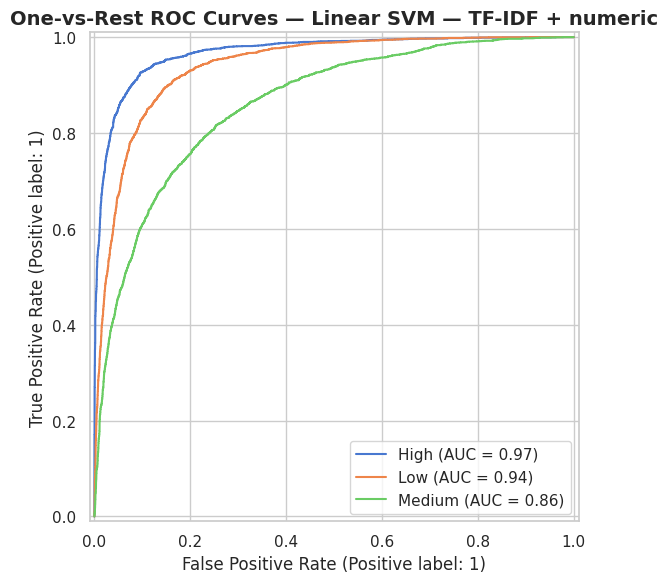

In [18]:

if best_scores is None:
    print("Best model does not expose predict_proba or decision_function. Skipping ROC curves.")
else:
    y_test_bin = label_binarize(y_test, classes=np.arange(len(label_classes)))

    plt.figure(figsize=(8, 6))
    ax = plt.gca()

    for class_idx, class_name in enumerate(label_classes):
        RocCurveDisplay.from_predictions(
            y_test_bin[:, class_idx],
            best_scores[:, class_idx],
            name=f"{class_name}",
            ax=ax,
        )

    plt.title(f"One-vs-Rest ROC Curves — {best_model_name}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


### Linear model coefficient interpretation

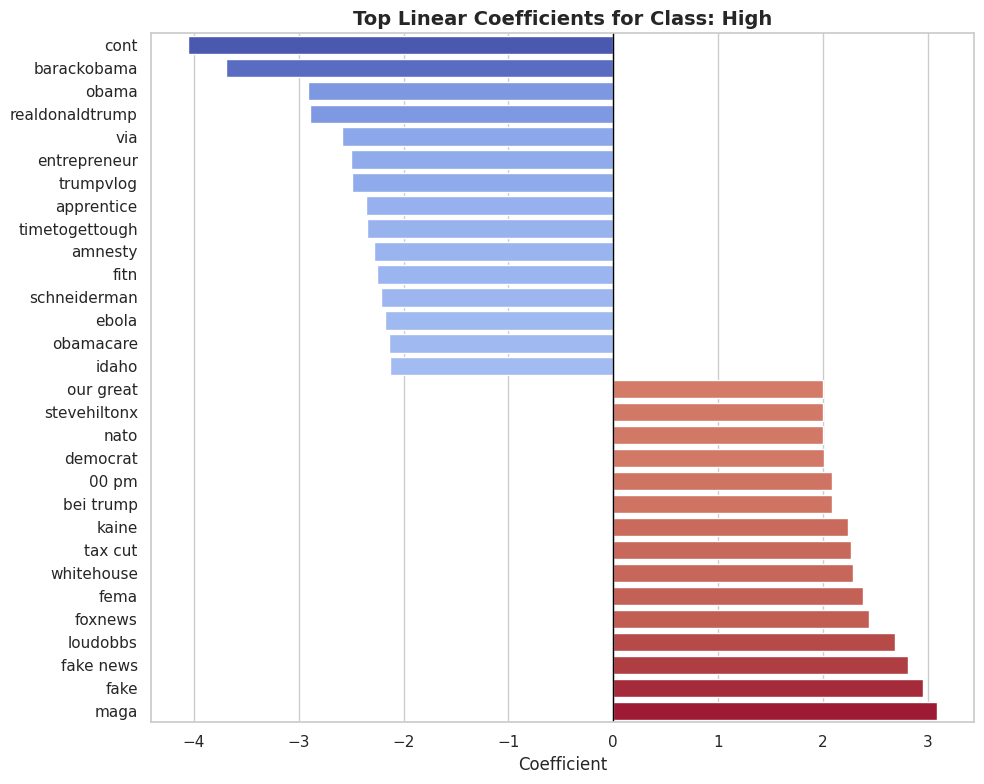

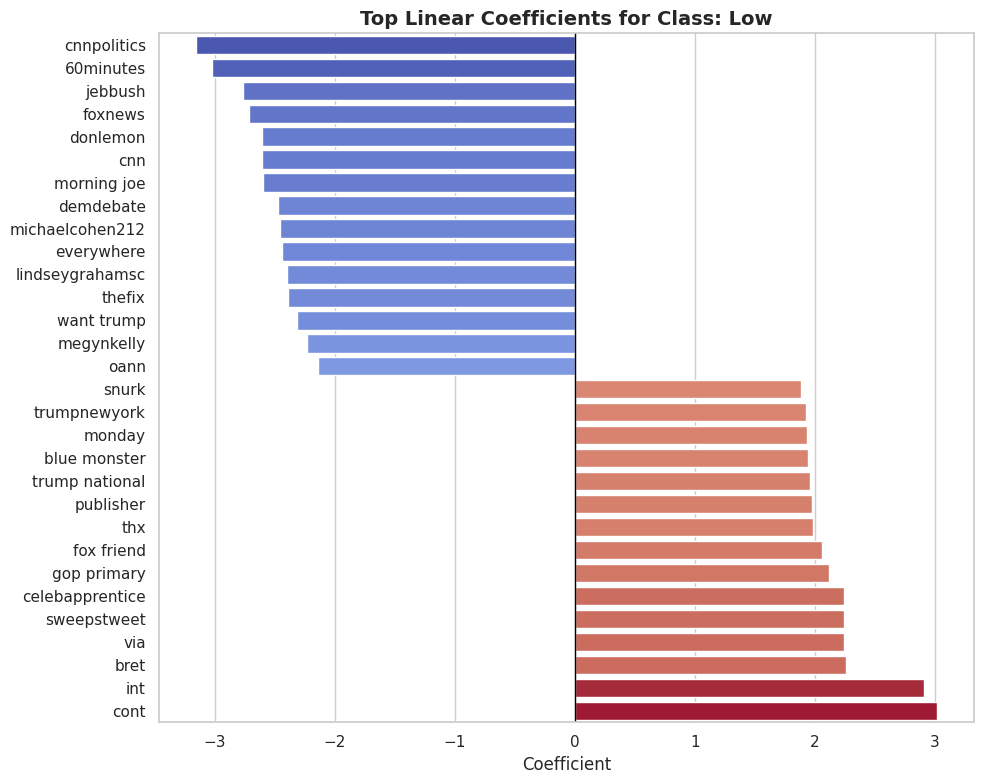

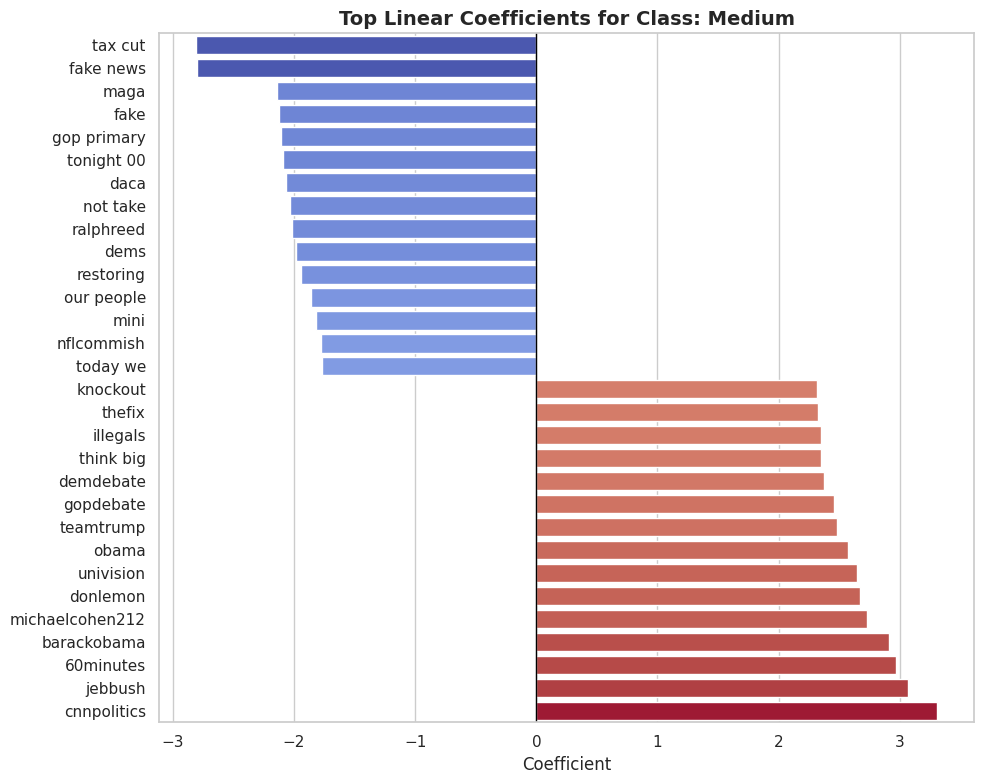

In [19]:

def plot_top_linear_features(model, feature_names, class_names, top_n=15):
    if not hasattr(model, "coef_"):
        print(f"Model {type(model).__name__} has no coef_ attribute. Skipping coefficient plots.")
        return

    coef = model.coef_
    if coef.ndim == 1:
        coef = coef.reshape(1, -1)

    n_classes_to_plot = min(len(class_names), coef.shape[0])

    for class_idx in range(n_classes_to_plot):
        class_name = class_names[class_idx]
        class_coef = coef[class_idx]
        top_pos_idx = np.argsort(class_coef)[-top_n:]
        top_neg_idx = np.argsort(class_coef)[:top_n]
        selected_idx = np.concatenate([top_neg_idx, top_pos_idx])

        coef_df = pd.DataFrame({
            "feature": [feature_names[i] for i in selected_idx],
            "coefficient": class_coef[selected_idx],
        }).sort_values("coefficient")

        plt.figure(figsize=(10, 8))
        sns.barplot(data=coef_df, x="coefficient", y="feature", hue="coefficient", legend=False, palette="coolwarm")
        plt.axvline(0, color="black", linewidth=1)
        plt.title(f"Top Linear Coefficients for Class: {class_name}", fontsize=14, fontweight="bold")
        plt.xlabel("Coefficient")
        plt.ylabel("")
        plt.tight_layout()
        plt.show()

plot_top_linear_features(best_model, best_feature_names, label_classes, top_n=15)


### Error analysis

In [20]:

if df is None:
    print("df_with_features.csv was not loaded; skipping tweet-level error analysis.")
else:
    test_df = df.iloc[test_idx].copy()
    test_df["actual_label"] = [label_classes[i] for i in y_test]
    test_df["predicted_label"] = [label_classes[i] for i in best_pred]
    test_df["is_correct"] = test_df["actual_label"] == test_df["predicted_label"]

    if best_scores is not None:
        test_df["prediction_score_max"] = np.max(best_scores, axis=1)

    error_cols = ["content", "retweets", "engagement_level", "actual_label", "predicted_label", "is_correct"]
    if "prediction_score_max" in test_df.columns:
        error_cols.append("prediction_score_max")

    mistakes = test_df.loc[~test_df["is_correct"], error_cols].copy()
    print(f"Mistakes: {len(mistakes)} / {len(test_df)}")

    with pd.option_context("display.max_colwidth", 180, "display.max_columns", None):
        display(mistakes.head(20))

    mistakes.to_csv(DATA_DIR / "best_model_misclassified_examples.csv", index=False)


Mistakes: 1671 / 8671


,content,retweets,engagement_level,actual_label,predicted_label,is_correct,prediction_score_max
31657,I will be interviewed on @ foxandfriends by @ ainsleyearhardt starting at 6:00 A.M. Enjoy!,3836,Medium,Medium,High,False,0.398447
29726,""" @ DavidWohl: Barack is offended that @ realDonaldTrump will demand that # NATO allies pay their fair share. # DemsInPhilly""",6670,High,High,Medium,False,0.237170
23517,""" @ Samstwitch: Bill O'Reilly's interview with Trump:Q&A over what Trump would do as President!Definitely has my vote! https://youtu.be/vJkaLFGFSgE",157,Medium,Medium,Low,False,0.547035
6074,Little @ MacMiller—I have more hair than you do and there’s a slight age difference.,3303,Medium,Medium,Low,False,-0.188068
4772,The Countryside Party just formed in Scotland to fight ugly wind turbines & @ AlexSalmond. Congrats to Jim Crawford & Countryside Party.,36,Low,Low,Medium,False,-0.210069
9136,Ivanka and Joan Rivers will be working hard tonight at the Live Finale - everybody must watch the OPENING at 9.,49,Low,Low,Medium,False,-0.057356
27030,It is a shame that the biased media is able to so incorrectly define a word for the public when they know that the definition is wrong. Sad!,1768,Medium,Medium,High,False,1.089223
11030,"Good.morning, I'm going to work!",2041,Medium,Medium,Low,False,0.442793
6234,My @ TMZ interview with @ HarveyLevinTMZ discussing how I will see my $5M lawsuit against @ billmaher to the endhttp://tmz.me/XVAiI1,64,Medium,Medium,Low,False,1.681801
18468,"""@JackieKarlsen: Donald Trump Sends $25,000 To Recently Released Sgt. Andrew Tahmooressi http://www.westernjournalism.com/donald-trump-sends-25000-recently-released-sgt-andrew-...",56,Medium,Medium,High,False,-0.417652


### Save best model and benchmark artifacts

In [21]:

model_bundle = {
    "model_name": best_model_name,
    "model": best_model,
    "feature_names": best_feature_names,
    "label_classes": label_classes,
    "train_idx": train_idx,
    "test_idx": test_idx,
    "results": results_df,
    "methodological_note": (
        "Features were loaded from notebook 03, where vectorization/scaling/topic modeling "
        "were fitted on the full dataset for project simplicity. For strict evaluation, "
        "these steps should be placed inside a training-only sklearn Pipeline."
    ),
}

joblib.dump(model_bundle, MODELS_DIR / "best_engagement_model.joblib")

predictions_df = pd.DataFrame({
    "row_index": test_idx,
    "y_true": y_test,
    "y_pred": best_pred,
    "true_label": [label_classes[i] for i in y_test],
    "predicted_label": [label_classes[i] for i in best_pred],
})
predictions_df.to_csv(DATA_DIR / "best_model_test_predictions.csv", index=False)

print("Saved:")
print("-", MODELS_DIR / "best_engagement_model.joblib")
print("-", DATA_DIR / "model_benchmark_results.csv")
print("-", DATA_DIR / "best_model_classification_report.csv")
print("-", DATA_DIR / "best_model_test_predictions.csv")
print("-", DATA_DIR / "train_indices.npy")
print("-", DATA_DIR / "test_indices.npy")


Saved:
- /home/patryk/Programming/MIO/social-media-engagement-prediction/models/best_engagement_model.joblib
- /home/patryk/Programming/MIO/social-media-engagement-prediction/data/processed/model_benchmark_results.csv
- /home/patryk/Programming/MIO/social-media-engagement-prediction/data/processed/best_model_classification_report.csv
- /home/patryk/Programming/MIO/social-media-engagement-prediction/data/processed/best_model_test_predictions.csv
- /home/patryk/Programming/MIO/social-media-engagement-prediction/data/processed/train_indices.npy
- /home/patryk/Programming/MIO/social-media-engagement-prediction/data/processed/test_indices.npy
